# Pseudobulk QC and minimal biological reproduction

## tl;dr

94개 주 코호트의 `log1p(CPM)` 반응 행렬을 생성했다. DMSO 6h–24h 상관은
높지만 시간/원자료 차이의 크기가 약물 반응과 비슷하므로 pooled control은
민감도 분석에만 사용한다. 사전 지정한 8개 immediate-early MAPK marker는
평균적으로 모두 억제 방향이다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/qc_summary.json").read_text())
control_qc = pd.read_csv(root / "results/tables/control_time_qc.csv")
markers = pd.read_csv(root / "results/tables/marker_response_summary.csv")

key_metrics = pd.DataFrame({
    "metric": [
        "QC genes", "DMSO 6h–24h median PCC", "DMSO time/source median RMSE",
        "Trametinib response median RMSE", "control/treatment RMSE ratio"
    ],
    "value": [
        summary["qc_gene_rule"]["gene_count"],
        summary["control_time_all_97"]["median_pcc"],
        summary["strict_94_comparison"]["median_control_time_rmse"],
        summary["strict_94_comparison"]["median_trametinib_response_rmse"],
        summary["strict_94_comparison"]["median_control_to_treatment_rmse_ratio"],
    ],
})
display(key_metrics)


,metric,value
0,QC genes,16843.000000
1,DMSO 6h–24h median PCC,0.972675
2,DMSO time/source median RMSE,0.405450
3,Trametinib response median RMSE,0.453556
4,control/treatment RMSE ratio,0.887909


## Context & Methods

### Key Assumptions

- pseudobulk는 cell line × condition별 raw UMI 합이다.
- 정규화는 `log1p(1e6 × count / library_size)`로 고정한다.
- DMSO 시간/원자료 QC 유전자는 두 control에서 총 count ≥100이고 각 시점
  10개 이상 세포주에서 발현된 16,843개다.
- 이 QC gene mask는 기술적 비교용이며 모델 feature selection에는 사용하지 않는다.
- marker 평균의 구간은 seed 20260827, 2,000회 cell-line bootstrap이다.

## Data

In [3]:
from yakseopdong.pseudobulk import read_vector_parquet

primary_meta, primary_matrix = read_vector_parquet(
    root / "data/processed/pseudobulk_24h.parquet", "log1p_cpm"
)
response_meta, response_matrix = read_vector_parquet(
    root / "data/processed/response_24h.parquet", "delta_log1p_cpm"
)
print("pseudobulk_24h", primary_meta.shape, primary_matrix.shape)
print("response_24h", response_meta.shape, response_matrix.shape)
display(pd.read_csv(root / "processed_manifest.csv"))
assert primary_matrix.shape == (188, 32_738)
assert response_matrix.shape == (94, 32_738)


pseudobulk_24h (188, 7) (188, 32738)
response_24h (94, 5) (94, 32738)


,path,row_count,vector_length,value_column,bytes,sha256,genes_tsv_sha256
0,data/processed/gene_metadata.parquet,32738,0,NaN,398245,e33fa6fb3f12fa626c15f2ac5ee1efffa86ad96b87811a...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...
1,data/processed/pseudobulk_24h.parquet,188,32738,log1p_cpm,6901235,9f175d3094e5b13359ce34c094cf1c5664f05dee4eda79...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...
2,data/processed/pseudobulk_control_time.parquet,194,32738,log1p_cpm,6922472,ee0642afa44119dbd774134a02d266f7d85a9ee6a37ffd...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...
3,data/processed/pseudobulk_pooled_sensitivity.p...,194,32738,log1p_cpm,7295408,b561a24ff7a2c3e03232835e9aee730bd3a47d875964ba...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...
4,data/processed/response_24h.parquet,94,32738,delta_log1p_cpm,5645252,00fa6424336d51947e9b69047fc4e25ae97d50db170706...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...
5,data/processed/response_pooled_sensitivity.par...,97,32738,delta_log1p_cpm,5995983,1dd3c7152a5af23347641395ba8365a6b628185aa492c0...,8778dd78085086be6dcafa8334f95f7cf76b25526e8ef2...


## Results

,gene_symbol,gene_id,n_cell_lines,mean_delta_log1p_cpm,median_delta_log1p_cpm,ci95_low,ci95_high,fraction_negative
0,EGR1,ENSG00000120738,94,-2.669841,-2.766985,-2.826488,-2.503505,1.000000
1,ETV4,ENSG00000175832,94,-2.467274,-2.485204,-2.649295,-2.279155,1.000000
2,ETV5,ENSG00000244405,94,-1.875740,-1.854704,-2.035531,-1.714960,0.989362
3,DUSP4,ENSG00000120875,94,-1.431943,-1.347769,-1.602225,-1.273593,0.978723
4,DUSP5,ENSG00000138166,94,-1.106030,-1.103428,-1.233091,-0.981565,0.968085
5,DUSP6,ENSG00000139318,94,-2.394439,-2.242372,-2.577554,-2.210095,1.000000
6,SPRY2,ENSG00000136158,94,-0.996646,-0.824102,-1.146335,-0.849108,0.946809
7,SPRY4,ENSG00000187678,94,-1.305015,-1.275796,-1.446934,-1.167591,0.978723


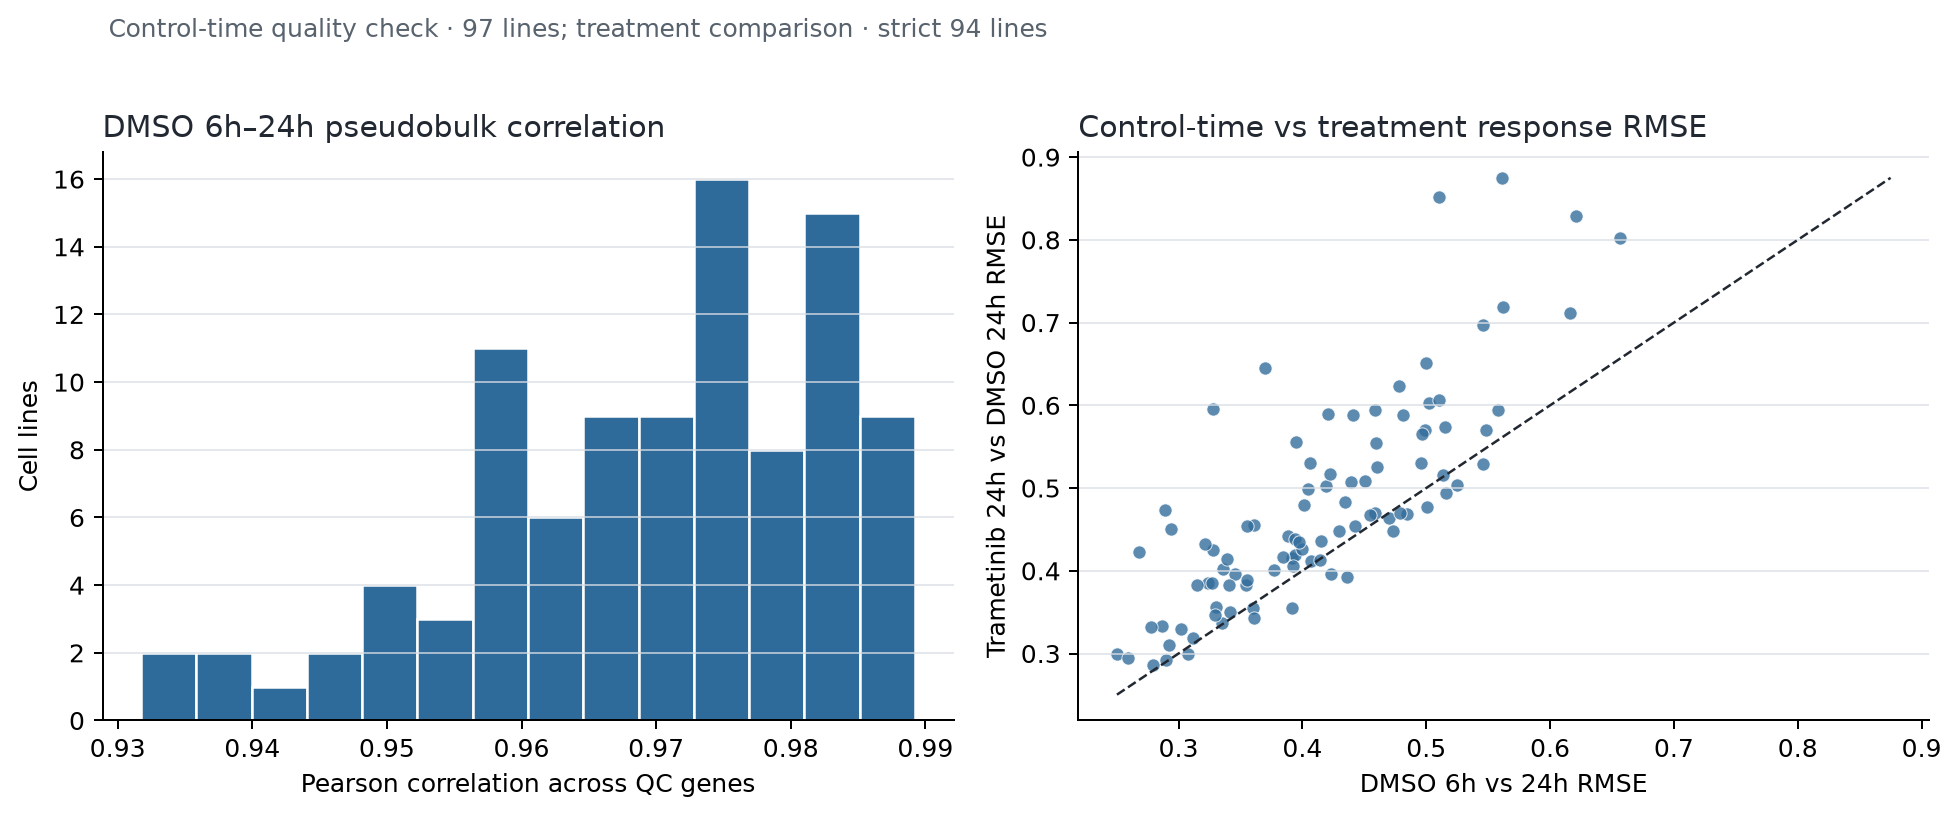

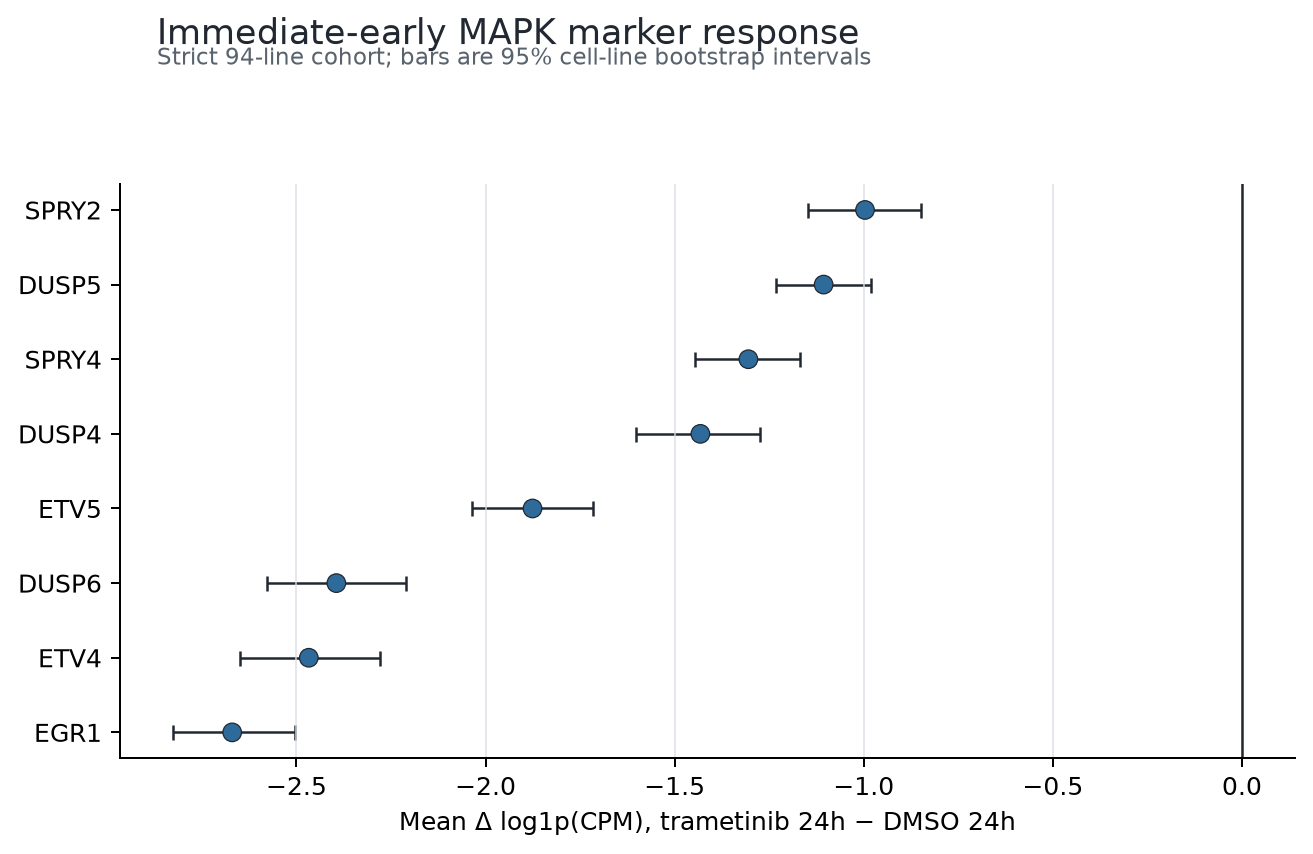

In [4]:
display(markers)
assert (markers["mean_delta_log1p_cpm"] < 0).all()
assert summary["pooling_used_for_primary"] is False
display(Image(filename=str(root / "results/figures/control_time_qc.png")))
display(Image(filename=str(root / "results/figures/marker_response.png")))


## Takeaways

- DMSO 6h–24h 중앙 PCC는 약 0.973으로 전체 발현 순서는 안정적이다.
- 그러나 strict 94-line에서 control 시간/원자료 RMSE는 trametinib 반응
  RMSE의 중앙 약 0.888이다. 이는 pooling 효과를 무시하기 어렵다는 뜻이다.
- EGR1과 DUSP6는 94개 세포주 모두 억제 방향이며, 사전 지정한 8개 marker의 평균 반응도 모두 음수다.
- 따라서 주 target은 DMSO 24h time-matched 반응으로 동결하고
  pooled-control은 민감도 분석으로만 유지한다.
- 이 비교는 시간과 archive/batch 차이가 섞인 관찰적 QC이므로 순수한 시간
  인과효과로 해석하지 않는다.